# 05 · Successions i criteri de Cauchy

[Obre aquest quadern a Google Colab](https://colab.research.google.com/github/mlacasa/1BATXILLERAT/blob/main/05_Successions_Cauchy.ipynb)

**Matemàtiques · 1r de batxillerat**  
**Autoria: Dr. Lacasa-Cazcarra · Any 2026**

**Objectiu.** Distingir convergència, acotació i condició de Cauchy, i precisar els quantificadors.

**Abans de començar:** successions elementals i quadern 01  
**Temps orientatiu:** 2 sessions. Hi ha activitats bàsiques i ampliacions opcionals.

**Funcionament.** Executa les cel·les en ordre, des del començament. Primer fes una predicció,
després experimenta i escriu una justificació. Els controls són opcionals: també pots
modificar els arguments de les funcions i executar-les. Les figures representen mostres
finites; les propietats infinites necessiten una demostració.

**Procedència.** Quadern nou del recorregut de fonaments.


In [1]:
import math
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "font.size": 11, "figure.dpi": 100})

def explora(funcio, **rangs):
    """Controls opcionals: la mateixa funció també es pot cridar directament."""
    # Conservem un exemple estàtic per als lectors sense controls interactius.
    funcio()
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Sense controls: executem els paràmetres per defecte. Pots canviar-los a la crida.")
        return None
    panell = widgets.interactive(funcio, **rangs)
    display(panell)
    return panell


## Ruta guiada per a 1r de batxillerat

**Pregunta de partida:** Si els passos es fan petits, necessàriament ens acabem aturant prop d'un nombre?

**Al final ho has de poder explicar:** Distingir estar a prop del terme següent d'estar a prop de tots els termes prou avançats.

La primera lectura combina l'exemple resolt amb el **laboratori animat** i les preguntes
que l'acompanyen. Els apartats marcats com a ampliació formal aprofundeixen en el rigor;
no cal entendre tot el codi per interpretar la matemàtica.

Dedica 2 minuts a una predicció escrita, 8–10 minuts a experimentar i pausar,
i 5 minuts a justificar una conclusió amb càlculs. Després resol el repte amb dades noves.
L'animació té controls de reproducció, pausa i selecció de fotograma.
Si el visor no mostra HTML interactiu, el fotograma estàtic i la funció
`fotograma_laboratori(...)` permeten fer la mateixa activitat pas a pas després d'executar el codi.


## 1. Apropar-se a un límit o apropar-se entre si
$a_n\to L$ significa:
$$\forall\varepsilon>0\ \exists N\ \forall n\ge N:\ |a_n-L|<\varepsilon.$$
Una successió és **de Cauchy** si:
$$\forall\varepsilon>0\ \exists N\ \forall m,n\ge N:\ |a_m-a_n|<\varepsilon.$$
La segona definició no necessita conèixer L. L'índex N pot dependre d'ε,
però ha de servir per a **tots dos índexs** m i n de la cua infinita.

Prediu què passarà amb $1/n$, $(-1)^n$ i les sumes harmòniques.


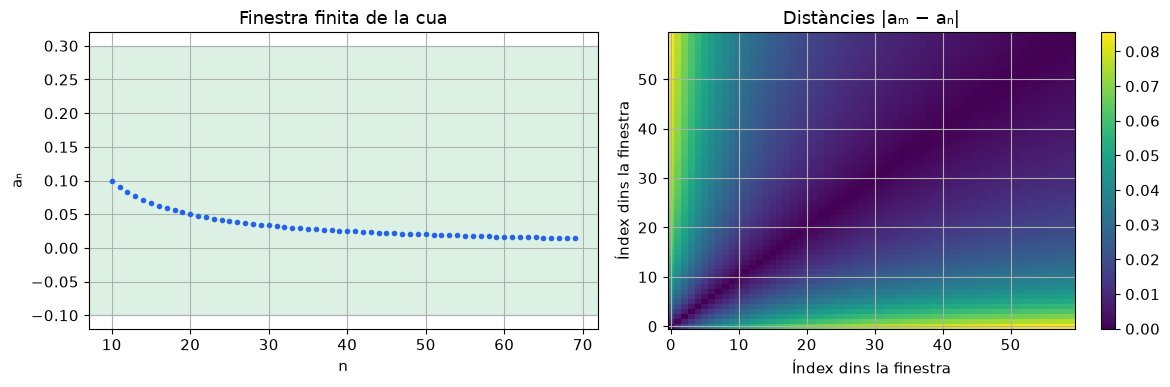

Diàmetre mostrat = 0.0855072; ε = 0.2
Totes les parelles MOSTRADES compleixen la desigualtat: True
Una comprovació finita no certifica una cua infinita.


interactive(children=(Dropdown(description='tipus', options=('inversa', 'alternant', 'harmonica'), value='inve…

In [2]:
def valors_successio(tipus, maxim):
    n = np.arange(1, maxim+1)
    if tipus == "inversa":
        return 1/n
    if tipus == "alternant":
        return (-1.0)**n
    if tipus == "harmonica":
        return np.cumsum(1/n)
    raise ValueError("Successió desconeguda.")

def laboratori_cauchy(tipus="inversa", N=10, finestra=60, epsilon=0.2):
    valors = valors_successio(tipus, N+finestra-1)
    cua = valors[N-1:]
    diametre = float(np.max(cua)-np.min(cua))
    fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4))
    ax.plot(np.arange(N, N+finestra), cua, ".", color="#2563eb")
    ax.axhspan(cua[0]-epsilon, cua[0]+epsilon, alpha=.15, color="#16a34a")
    ax.set(xlabel="n", ylabel="aₙ", title="Finestra finita de la cua")
    distancies = np.abs(cua[:, None]-cua[None, :])
    im = bx.imshow(distancies, origin="lower", aspect="auto", cmap="viridis")
    bx.set(xlabel="Índex dins la finestra", ylabel="Índex dins la finestra", title="Distàncies |aₘ − aₙ|")
    fig.colorbar(im, ax=bx); plt.tight_layout(); plt.show()
    print(f"Diàmetre mostrat = {diametre:.6g}; ε = {epsilon}")
    print("Totes les parelles MOSTRADES compleixen la desigualtat:", diametre < epsilon)
    print("Una comprovació finita no certifica una cua infinita.")
panell = explora(laboratori_cauchy, tipus=["inversa", "alternant", "harmonica"],
                 N=(1, 300, 1), finestra=(10, 150, 10), epsilon=(.01, 2.1, .01))


## Laboratori animat · observa, atura i explica


### Passos petits, recorregut encara gran

Comparem dos recorreguts. En $a_n=1/n$, els valors s'apropen a 0.
En $H_n=1+1/2+\cdots+1/n$, cada increment és petit, però sempre sumem més.

| Pregunta | Successió $1/n$ | Sumes harmòniques $H_n$ |
|---|---|---|
| Distància del terme n al següent | $1/[n(n+1)]$ | $1/(n+1)$ |
| Distància del terme n al terme 2n | $1/(2n)$ | $1/(n+1)+\cdots+1/(2n)$ |

Per a les sumes harmòniques, l'últim bloc conté **n sumands**, cadascun almenys $1/(2n)$.
Per tant $H_{2n}-H_n\ge n\cdot1/(2n)=1/2$. Això continua sent cert per gran que sigui n.

**Prediu.** Quin dels dos gràfics tindrà els punts de n i 2n cada vegada més junts?
**Pausa.** Compara la distància entre n i n+1 amb la distància entre n i 2n. Els eixos
horitzontals mostren cada vegada més termes; els títols indiquen les distàncies numèriques.

La definició de Cauchy exigeix controlar **totes les parelles prou avançades**.
La pel·lícula suggereix el comportament; la desigualtat anterior refuta Cauchy per a $H_n$.


In [3]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def fotograma_laboratori(pas):
    """Mostra un estat quiet per poder llegir, dibuixar i prendre apunts."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=90)
    dibuixa_laboratori(pas, axes)
    fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .92))
    plt.show()

def anima_laboratori():
    """Animació HTML amb pausa i desplaçament manual; no necessita FFmpeg."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=80)
    def actualitza(pas):
        for ax in axes:
            ax.clear()
        dibuixa_laboratori(pas, axes)
        fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
        fig.tight_layout(rect=(0, 0, 1, .92))
    animacio = FuncAnimation(fig, actualitza, frames=fotogrames_laboratori,
                             interval=700, repeat=False, cache_frame_data=False)
    try:
        contingut = animacio.to_jshtml(fps=1.5, default_mode="once")
    finally:
        plt.close(fig)
    return HTML(contingut)


In [4]:
titol_laboratori = "Un salt petit no controla tots els salts futurs"
fotogrames_laboratori = [2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64, 96, 128, 192]

def distancies_cauchy(n):
    return 1/(n*(n+1)), 1/(2*n), 1/(n+1), float(np.sum(1/np.arange(n+1, 2*n+1)))

def dibuixa_laboratori(n, axes):
    salt_a, bloc_a, salt_h, bloc_h = distancies_cauchy(n)
    indices = np.arange(1, 2*n+1)
    inversa = 1/indices
    harmonica = np.cumsum(1/indices)
    for ax, dades, color, titol in zip(axes, [inversa, harmonica], ["#2563eb", "#ea580c"],
                                     ["aₙ = 1/n", "Hₙ = 1 + 1/2 + … + 1/n"]):
        ax.plot(indices, dades, color=color)
        ax.scatter([n, 2*n], dades[[n-1, 2*n-1]], color=color, s=65, zorder=5)
        ax.axvspan(n, 2*n, color=color, alpha=.1)
        ax.plot([n, 2*n], [dades[n-1], dades[n-1]], ":", color=color)
        ax.plot([2*n, 2*n], [dades[n-1], dades[-1]], color="#b91c1c", lw=3)
        ax.set(xlim=(0, 2*n*1.12), xlabel="Índex del terme", ylabel="Valor del terme")
    axes[0].set(ylim=(0, 1.05), title=f"1/n: n = {n}\nSalt següent: {salt_a:.5f}; fins a 2n: {bloc_a:.5f}")
    axes[1].set(ylim=(0, 7), title=f"Sumes harmòniques: n = {n}\nSalt següent: {salt_h:.5f}; fins a 2n: {bloc_h:.5f}")


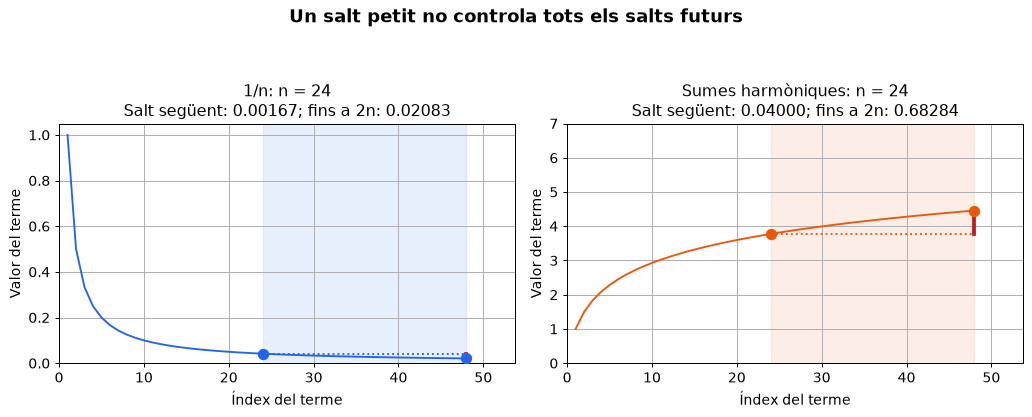

In [5]:
# Fotograma visible també quan no es reprodueix l'animació.
fotograma_laboratori(fotogrames_laboratori[len(fotogrames_laboratori)//2])


**Ara reprodueix l'animació.** Fes servir la pausa i el control de fotograma per contrastar la teva predicció. Els valors numèrics dels títols formen part de l'explicació.


In [6]:
display(anima_laboratori())


### Compara abans de concloure

Compara n=4 amb n=128. Anota el salt consecutiu i la distància fins a 2n en les dues successions. Identifica quina d'aquestes distàncies continua sent més gran que 1/2.

Tria dos estats amb els controls i prem **Compara els estats**. Llegeix les escales: algunes ampliacions del laboratori canvien els límits dels eixos. Justifica la comparació amb els nombres dels títols.


In [7]:
parella_comparacio = (4, 128)
etiquetes_comparacio = [f"n = {n}" for n in fotogrames_laboratori]
preguntes_taller = [{'enunciat': 'Els salts Hₙ₊₁−Hₙ tendeixen a 0. Això demostra que Hₙ és de Cauchy?', 'opcions': ['Sí', 'Només si n supera 100', 'No: cal controlar totes les parelles prou avançades'], 'correcta': 2, 'retorn': ['Els salts acumulats fins a 2n no es fan petits: són almenys 1/2.', 'Cap llindar finit repara el problema dels salts entre n i 2n.', 'Correcte: Cauchy és una condició sobre totes les parelles de la cua.']}, {'enunciat': 'La successió (−1)ⁿ és acotada. És de Cauchy?', 'opcions': ['No, perquè termes de paritat diferent disten 2', 'Sí, perquè tots els termes estan entre −1 i 1', 'Sí, perquè alguns termes coincideixen'], 'correcta': 0, 'retorn': ['Correcte: podem trobar aquestes parelles per molt lluny que avancem.', "L'acotació no implica que tots els termes de la cua s'apropin entre si.", 'Cauchy no exigeix només algunes parelles properes, sinó totes.']}, {'enunciat': 'Per a 1/n, quin N és suficient perquè qualsevol parella amb índexs ≥N disti menys de 0,01?', 'opcions': ['N=10', 'N=100', 'No existeix'], 'correcta': 1, 'retorn': ['Amb N=10 la cota 1/N és 0,1 i no assegura la tolerància demanada.', 'Correcte: per a índexs finits m,n≥100, la distància és estrictament menor que 1/100.', 'La successió 1/n sí que és de Cauchy: la cota 1/N es pot fer tan petita com calgui.']}]


In [8]:
def compara_estats(inicial, final):
    """Dos fotogrames simultanis; els eixos conserven el significat del laboratori."""
    if inicial not in fotogrames_laboratori or final not in fotogrames_laboratori:
        raise ValueError("Tria dos estats de fotogrames_laboratori.")
    fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), dpi=90)
    for fila, estat, lletra in [(0, inicial, "A"), (1, final, "B")]:
        dibuixa_laboratori(estat, axes[fila])
        for ax in axes[fila]:
            ax.set_title(lletra + " · " + ax.get_title(), fontsize=10)
    fig.suptitle("Comparació simultània: observa què canvia i què es conserva", fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .95), h_pad=3)
    plt.show()

def controls_comparacio():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Canvia els dos arguments de compara_estats(...) per fer una altra comparació.")
        return None
    opcions = list(zip(etiquetes_comparacio, fotogrames_laboratori))
    panell = widgets.interactive(compara_estats, {"manual": True, "manual_name": "Compara els estats"},
        inicial=widgets.Dropdown(options=opcions, value=parella_comparacio[0], description="Estat A:"),
        final=widgets.Dropdown(options=opcions, value=parella_comparacio[1], description="Estat B:"))
    display(panell)
    return panell

def feedback_resposta(numero, lletra):
    """Retorn per opció. Ex.: feedback_resposta(1, 'B'); no desa ni envia respostes."""
    if isinstance(numero, bool) or not isinstance(numero, int) or not 1 <= numero <= len(preguntes_taller):
        raise ValueError("El número de pregunta no és vàlid.")
    q = preguntes_taller[numero-1]
    lletra = str(lletra).strip().upper()
    lletres = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[:len(q["opcions"])]
    if lletra not in lletres or len(lletra) != 1:
        raise ValueError("Tria una de les lletres de les opcions.")
    index = lletres.index(lletra)
    return {"correcte": index == q["correcta"], "explicacio": q["retorn"][index]}

def mostra_feedback(numero, lletra):
    resultat = feedback_resposta(numero, lletra)
    estat = "Resposta encertada" if resultat["correcte"] else "Revisa el raonament"
    display(Markdown(f"**Pregunta {numero} · {estat}.** {resultat['explicacio']}"))
    return resultat

def crea_autoavaluacio():
    try:
        import ipywidgets as widgets
        from html import escape
    except ImportError:
        print("Respon amb mostra_feedback(1, 'A'), canviant la pregunta i la lletra.")
        return None
    camps, selectors = [], []
    for numero, q in enumerate(preguntes_taller, 1):
        opcions = [("Tria una resposta", None)] + [
            (f"{chr(65+k)}. {text}", chr(65+k)) for k, text in enumerate(q["opcions"])]
        selector = widgets.Dropdown(options=opcions, value=None, layout=widgets.Layout(width="100%"))
        selectors.append(selector)
        camps.append(widgets.VBox([
            widgets.HTML(f"<b>{numero}. {escape(q['enunciat'])}</b>"), selector]))
    sortida = widgets.Output()
    boto = widgets.Button(description="Comprova i raona", button_style="info", layout=widgets.Layout(width="180px"))
    def comprova(_):
        with sortida:
            sortida.clear_output(wait=True)
            for numero, selector in enumerate(selectors, 1):
                if selector.value is None:
                    display(Markdown(f"**Pregunta {numero}:** encara has de triar una resposta."))
                else:
                    mostra_feedback(numero, selector.value)
    def canvi(_):
        sortida.clear_output()
    for selector in selectors:
        selector.observe(canvi, names="value")
    boto.on_click(comprova)
    panell = widgets.VBox(camps+[boto, sortida])
    display(panell)
    return {"panell": panell, "selectors": selectors, "boto": boto, "sortida": sortida}


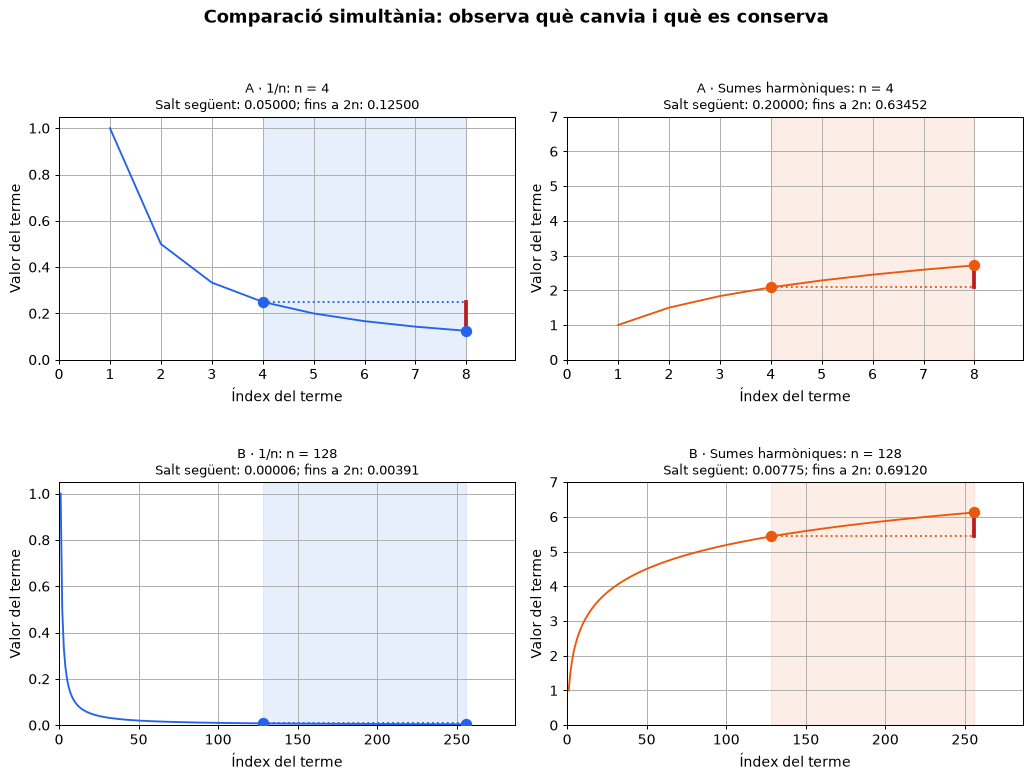

interactive(children=(Dropdown(description='Estat A:', index=2, options=(('n = 2', 2), ('n = 3', 3), ('n = 4',…

In [9]:
compara_estats(*parella_comparacio)
panell_comparacio = controls_comparacio()


### Taller de Python · canvia una dada i explica l'efecte

Escull N i compara tres successions. Per a 1/n i Hₙ examinem N i 2N; per a (−1)ⁿ examinem N i N+1 perquè els signes siguin diferents. Explica per què triar només una parella favorable no certifica Cauchy.

**Fes-ho en tres passos:** escriu una predicció, modifica les dades indicades i contrasta el resultat. Acaba amb una explicació matemàtica; executar la cel·la és només una part de la tasca.


In [10]:
N_taller = 100
epsilon_taller = 0.1
for tipus in ["inversa", "harmonica", "alternant"]:
    segon = N_taller+1 if tipus == "alternant" else 2*N_taller
    valors = valors_successio(tipus, segon)
    distancia = abs(valors[segon-1]-valors[N_taller-1])
    print(f"{tipus}: índexs {N_taller} i {segon}; distància={distancia:.6f}; "
          f"menor que ε: {distancia < epsilon_taller}")
print("Una parella que falla pot refutar una proposta de N; una que passa no controla tota la cua.")


inversa: índexs 100 i 200; distància=0.005000; menor que ε: True
harmonica: índexs 100 i 200; distància=0.690653; menor que ε: False
alternant: índexs 100 i 101; distància=2.000000; menor que ε: False
Una parella que falla pot refutar una proposta de N; una que passa no controla tota la cua.


### Atura't i comprova què has entès

Tria una resposta per pregunta i escriu una justificació abans de comprovar-la. Si t'equivoques, llegeix el retorn i torna al gràfic per localitzar el malentès.

**1. Els salts Hₙ₊₁−Hₙ tendeixen a 0. Això demostra que Hₙ és de Cauchy?**

- A. Sí
- B. Només si n supera 100
- C. No: cal controlar totes les parelles prou avançades

**2. La successió (−1)ⁿ és acotada. És de Cauchy?**

- A. No, perquè termes de paritat diferent disten 2
- B. Sí, perquè tots els termes estan entre −1 i 1
- C. Sí, perquè alguns termes coincideixen

**3. Per a 1/n, quin N és suficient perquè qualsevol parella amb índexs ≥N disti menys de 0,01?**

- A. N=10
- B. N=100
- C. No existeix

Si no es mostren els controls, executa `mostra_feedback(1, 'B')`, canviant el número i la lletra. El retorn comprova l'opció; la justificació escrita s'ha de discutir a classe.


In [11]:
autoavaluacio = crea_autoavaluacio()


### Evidència final de l'aprenentatge

Completa aquestes frases amb un cas concret del taller:

1. **He canviat…**
2. **Esperava que… perquè…**
3. **El resultat ha estat…**
4. **Ara ho explico amb aquesta relació o propietat…**
5. **Un cas en què no puc generalitzar directament és…**

Torna a una pregunta que hagis corregit i explica què has canviat del teu raonament.


### Investiga i transfereix


1. Per a $1/n$, si $m,n\ge N$, justifica que $|1/m-1/n|<1/N$.
   Tria un N que asseguri una distància menor que 0,01 entre **qualsevol** parella posterior.
2. A les sumes harmòniques, quin ε fix pots triar per refutar la condició de Cauchy?
   Per què sempre pots trobar una parella d'índexs prou gran que incompleix la condició?
3. Compara amb $(-1)^n$: és acotada? És de Cauchy? Dona una parella d'índexs que ho mostri.
4. Escriu una frase que corregeixi «Cauchy vol dir que dos termes consecutius estan molt junts».


### El teu raonament

Edita aquesta cel·la per deixar evidència del que has après.

- **Abans pensava que…**
- **He provat aquests valors…**
- **Al gràfic he observat…**
- **Ho justifico amb aquest càlcul o propietat…**
- **La meva conclusió i el seu límit són…**

No n'hi ha prou amb una captura: relaciona el dibuix, els nombres i l'explicació.


In [12]:
# Espai per al teu experiment: canvia l'índex i executa la cel·la.
# fotograma_laboratori(fotogrames_laboratori[0])
# Escriu aquí els càlculs del repte.


<details><summary>Comprovació: obre-la després d'intentar els reptes</summary>

N=100 ja serveix perquè la distància és estrictament menor que 1/N; N=101
també serveix. Per a $H_n$, ε=1/2 refuta la condició: tria n tan gran com calgui i m=2n.
La successió alternant és acotada entre −1 i 1, però un índex parell i un d'imparell
sempre donen distància 2. Cauchy exigeix proximitat entre qualsevol parella d'una cua prou avançada.

</details>

**Comprova el teu aprenentatge:** has interpretat els eixos i les unitats, justificat una predicció amb un càlcul i aplicat la idea a un cas nou? Una observació finita pot suggerir una propietat; una afirmació general necessita una justificació.


## 2. Tres justificacions, no només tres gràfiques · Ampliació formal
**$1/n$:** si $m,n\ge N$, $|1/m-1/n|<1/N$. Escollint $N>1/\varepsilon$,
la successió és de Cauchy i convergeix a 0.

**$(-1)^n$:** per a qualsevol N hi ha índexs parells i senars més grans que N,
amb distància 2. Prenent ε=1 refutem la condició de Cauchy. Estar acotada no basta.

**Harmònica:** els salts consecutius $H_{n+1}-H_n=1/(n+1)$ tendeixen a zero, però
$$H_{2n}-H_n=\sum_{k=n+1}^{2n}\frac1k\ge n\frac1{2n}=\frac12.$$
Per a ε=1/2, cap N serveix. Per això «els termes consecutius s'apropen» no és el criteri de Cauchy.


In [13]:
for n in (10, 100, 1000, 10000):
    bloc = np.sum(1 / np.arange(n+1, 2*n+1))
    print(f"n={n:5}: salt consecutiu ≈ {1/(n+1):.7f}; H₂ₙ−Hₙ ≈ {bloc:.7f}")


n=   10: salt consecutiu ≈ 0.0909091; H₂ₙ−Hₙ ≈ 0.6687714
n=  100: salt consecutiu ≈ 0.0099010; H₂ₙ−Hₙ ≈ 0.6906534
n= 1000: salt consecutiu ≈ 0.0009990; H₂ₙ−Hₙ ≈ 0.6928972
n=10000: salt consecutiu ≈ 0.0001000; H₂ₙ−Hₙ ≈ 0.6931222


In [14]:
def intervals_arrel2(passos=12):
    """Extrems racionals exactes. No calcula sqrt(2)."""
    if not isinstance(passos, int) or passos < 0:
        raise ValueError("El nombre de passos ha de ser un enter no negatiu.")
    a, b = Fraction(1), Fraction(2)
    intervals = [(a, b)]
    for _ in range(passos):
        m = (a + b) / 2
        if m * m < 2:
            a = m
        else:
            b = m
        intervals.append((a, b))
    return intervals


In [15]:
intervals = intervals_arrel2(20)
aproximacions = [(a+b)/2 for a, b in intervals]
for n in (2, 5, 10, 20):
    a, b = intervals[n]
    print(f"n={n}: terme racional {aproximacions[n]}; amplada exacta {b-a}")


n=2: terme racional 11/8; amplada exacta 1/4
n=5: terme racional 91/64; amplada exacta 1/32
n=10: terme racional 2897/2048; amplada exacta 1/1024
n=20: terme racional 2965821/2097152; amplada exacta 1/1048576


## 3. De Cauchy en ℚ, però sense límit en ℚ · Ampliació formal
Els punts mitjans $c_n$ dels intervals de bisecció són racionals.
Si $m,n\ge N$, tots dos són dins $[a_N,b_N]$, de manera que
$|c_m-c_n|\le2^{-N}$. Escollint $2^{-N}<\varepsilon$, demostrem que són de Cauchy.

Si tinguessin un límit racional r, les desigualtats $a_n^2<2<b_n^2$ i l'amplada
que tendeix a zero implicarien $r^2=2$, impossible pel quadern 01.
En ℝ sí que convergeixen: aquest és el paper de la completesa.

**Tota successió convergent és de Cauchy:** si a partir de N tots els termes són
a menys d'ε/2 de L, la desigualtat triangular dona
$|a_m-a_n|\le|a_m-L|+|L-a_n|<\varepsilon$.

## Activitats
1. Escriu un N que serveixi per a $a_n=1/n$ quan ε=0,001.
2. A la successió harmònica, augmenta N mantenint una finestra curta. Per què la
   pantalla pot suggerir una conclusió falsa? Torna a comparar n i 2n.
3. Explica amb paraules pròpies la diferència entre «per a tot» i «existeix» en la definició.
4. **Ampliació:** demostra que tota successió de Cauchy és acotada.

<details><summary>Pistes</summary>

N=1001 és suficient. Per a l'acotació, usa ε=1: tota la cua queda a distància
menor que 1 d'un terme fix. Els termes anteriors són un conjunt finit, també acotat.
Una finestra de longitud fixa pot ocultar distàncies grans entre índexs més separats.
</details>


**Navegació:** [Anterior](04_Talladures_Dedekind.ipynb) · [Índex i guia](README.md) · [Següent](06_Completesa_R.ipynb)
